LÊ TẤN KIỆT
MSSV:2474802010206
BÀI THỰC HÀNH LAB 4


CÂU 1

In [30]:
import pandas as pd

def load_data():
    data = pd.read_csv("titanic_disaster.csv")
    return data

df = load_data()

print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

CÂU 2

Số lượng dữ liệu thiếu trên mỗi cột:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


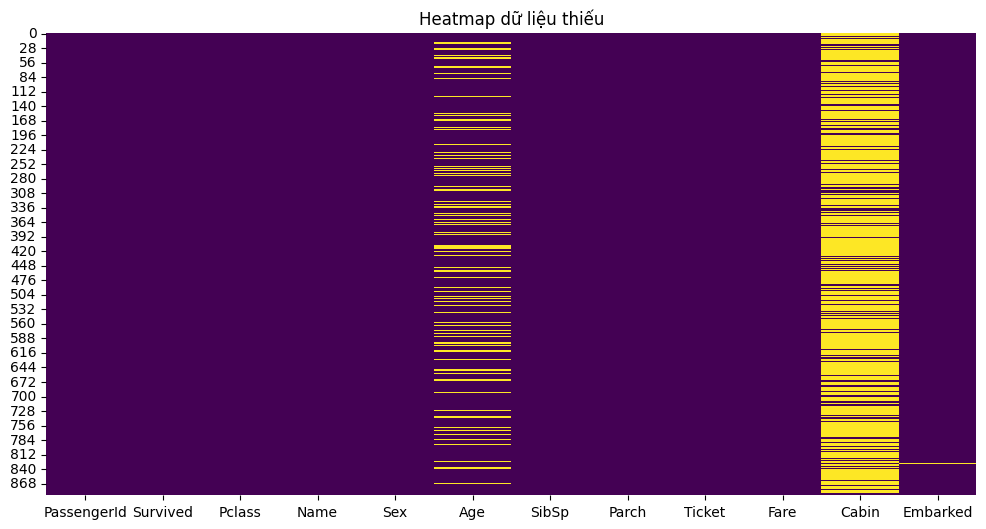

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("titanic_disaster.csv")

# Thống kê dữ liệu thiếu
print("Số lượng dữ liệu thiếu trên mỗi cột:")
print(df.isnull().sum())

# Vẽ Heatmap dữ liệu thiếu
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap dữ liệu thiếu")
plt.show()

CÂU 3

In [42]:
import pandas as pd

df = pd.read_csv("titanic_disaster.csv")

# Tách tên
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)

# Xóa cột Name
df.drop('Name', axis=1, inplace=True)

print(df.head())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch  \
0            1         0       3    male  22.0      1      0   
1            2         1       1  female  38.0      1      0   
2            3         1       3  female  26.0      0      0   
3            4         1       1  female  35.0      1      0   
4            5         0       3    male  35.0      0      0   

             Ticket     Fare Cabin Embarked  firstName  \
0         A/5 21171   7.2500   NaN        S     Braund   
1          PC 17599  71.2833   C85        C    Cumings   
2  STON/O2. 3101282   7.9250   NaN        S  Heikkinen   
3            113803  53.1000  C123        S   Futrelle   
4            373450   8.0500   NaN        S      Allen   

                                    secondName  
0                              Mr. Owen Harris  
1   Mrs. John Bradley (Florence Briggs Thayer)  
2                                  Miss. Laina  
3           Mrs. Jacques Heath (Lily May Peel)  
4                    

CÂU 4


In [33]:
import pandas as pd

df = pd.read_csv("titanic_disaster.csv")

# Thay thế giá trị
df['Sex'] = df['Sex'].replace({
    'male': 'M',
    'female': 'F'
})

print(df[['Sex']].head(10))

  Sex
0   M
1   F
2   F
3   F
4   M
5   M
6   M
7   M
8   F
9   F


CÂU 5 A

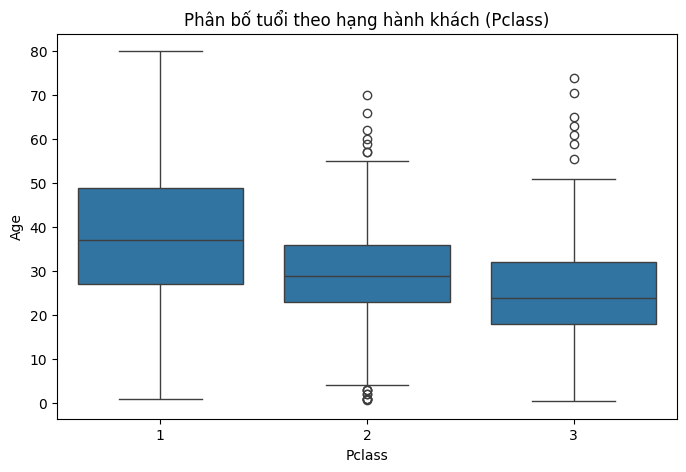

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("titanic_disaster.csv")

# Vẽ Box Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Pclass",
    y="Age",
    data=df
)

plt.title("Phân bố tuổi theo hạng hành khách (Pclass)")
plt.xlabel("Pclass")
plt.ylabel("Age")

plt.show()

CÂU 5B

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("titanic_disaster.csv")

# Thay Age bị thiếu bằng tuổi trung bình theo Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

# Kiểm tra dữ liệu thiếu
print(df['Age'].isnull().sum())

# Hiển thị kết quả
print(df[['Pclass','Age']].head(20))

0
    Pclass       Age
0        3  22.00000
1        1  38.00000
2        3  26.00000
3        1  35.00000
4        3  35.00000
5        3  25.14062
6        1  54.00000
7        3   2.00000
8        3  27.00000
9        2  14.00000
10       3   4.00000
11       1  58.00000
12       3  20.00000
13       3  39.00000
14       3  14.00000
15       2  55.00000
16       3   2.00000
17       2  29.87763
18       3  31.00000
19       3  25.14062


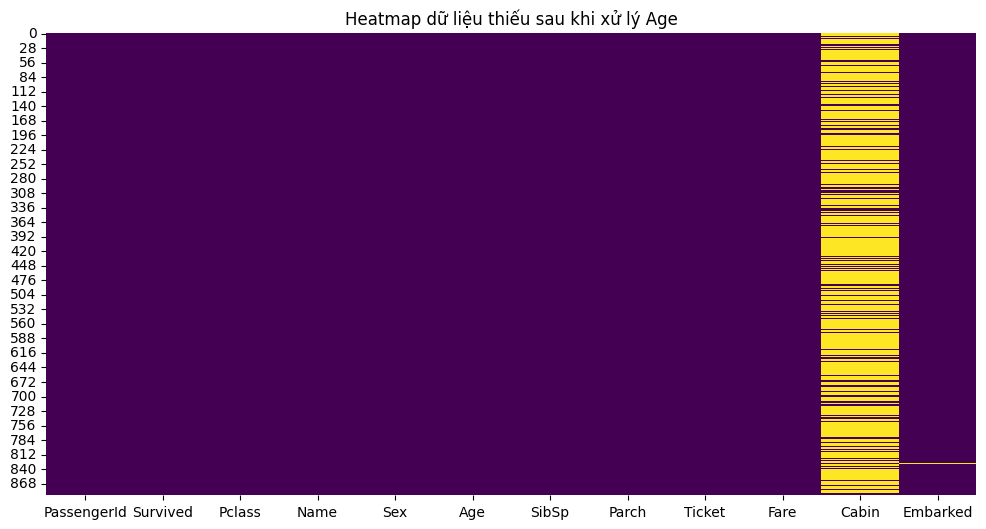

In [39]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Heatmap dữ liệu thiếu sau khi xử lý Age")
plt.show()

CÂU 6

In [40]:
def age_group(age):
    if age <= 12:
        return "Kid"
    elif age <= 18:
        return "Teen"
    elif age <= 60:
        return "Adult"
    else:
        return "Older"

df["Agegroup"] = df["Age"].apply(age_group)

print(df[["Age", "Agegroup"]].head(10))

        Age Agegroup
0  22.00000    Adult
1  38.00000    Adult
2  26.00000    Adult
3  35.00000    Adult
4  35.00000    Adult
5  25.14062    Adult
6  54.00000    Adult
7   2.00000      Kid
8  27.00000    Adult
9  14.00000     Teen


CÂU 7

In [43]:
# Tách danh xưng từ secondName
df["namePrefix"] = df["secondName"].str.extract(r'(Mr|Mrs|Miss|Master)')

# Hiển thị kết quả
print(df[["secondName", "namePrefix"]].head(10))

                                    secondName namePrefix
0                              Mr. Owen Harris         Mr
1   Mrs. John Bradley (Florence Briggs Thayer)         Mr
2                                  Miss. Laina       Miss
3           Mrs. Jacques Heath (Lily May Peel)         Mr
4                            Mr. William Henry         Mr
5                                    Mr. James         Mr
6                                Mr. Timothy J         Mr
7                        Master. Gosta Leonard     Master
8     Mrs. Oscar W (Elisabeth Vilhelmina Berg)         Mr
9                  Mrs. Nicholas (Adele Achem)         Mr


CÂU 8

In [44]:
df["familySize"] = 1 + df["SibSp"] + df["Parch"]

print(df[["SibSp", "Parch", "familySize"]].head(10))

   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2


CÂU 9

In [45]:
df["Alone"] = df["familySize"].apply(lambda x: 1 if x == 1 else 0)

print(df[["SibSp", "Parch", "familySize", "Alone"]].head(10))

   SibSp  Parch  familySize  Alone
0      1      0           2      0
1      1      0           2      0
2      0      0           1      1
3      1      0           2      0
4      0      0           1      1
5      0      0           1      1
6      0      0           1      1
7      3      1           5      0
8      0      2           3      0
9      1      0           2      0


CÂU 10

In [46]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

df["typeCabin"] = df["Cabin"].apply(
    lambda x: "Unknown" if x == "Unknown" else x[0]
)

print(df[["Cabin", "typeCabin"]].head(10))

     Cabin typeCabin
0  Unknown   Unknown
1      C85         C
2  Unknown   Unknown
3     C123         C
4  Unknown   Unknown
5  Unknown   Unknown
6      E46         E
7  Unknown   Unknown
8  Unknown   Unknown
9  Unknown   Unknown


PHẦN 2 : KHAI THÁC THÔNG TIN HỮU ÍCH - EDA

CÂU 12

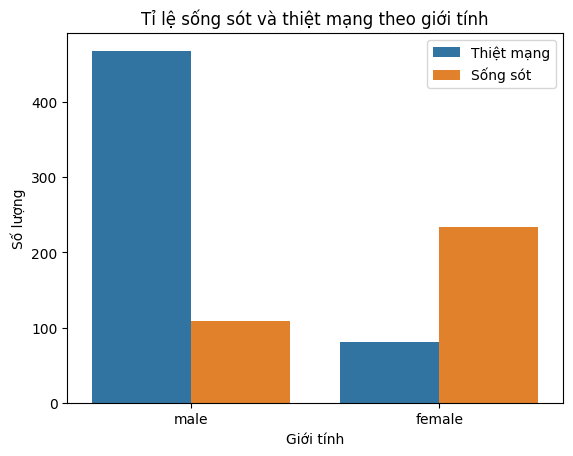

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Tỉ lệ sống sót và thiệt mạng theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng")
plt.legend(["Thiệt mạng", "Sống sót"])
plt.show()

NHẬN XÉT : DỰA VÀO BIỂU ĐỒ TRÊN TA THẤY TỈ LỆ SỐNG CỦA NỮ CAO HƠN NAM VÀ TỈ LỆ THIỆT MẠNG CỦA NAM LẠI CAO HƠN NỮ

CÂU 13


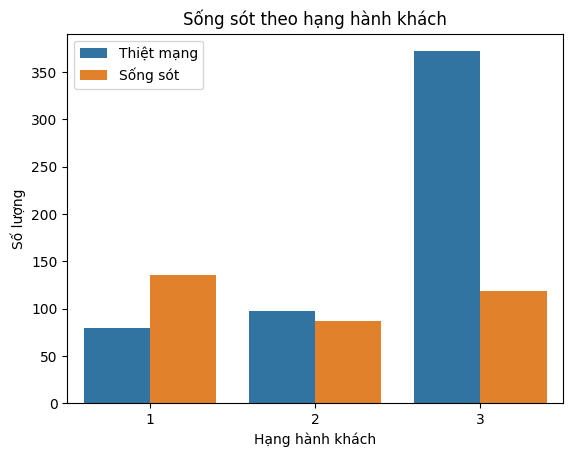

In [20]:
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Sống sót theo hạng hành khách")
plt.xlabel("Hạng hành khách")
plt.ylabel("Số lượng")
plt.legend(["Thiệt mạng", "Sống sót"])
plt.show()

NHẬN XÉT : DỰA VÀO BIỂU ĐỒ TRÊN TA THẤY TRONG 3 HẠNG HÀNH KHÁCH THI TỈ LỆ SỐNG SOT CỦA HÀNH KHÁCH 1 CAO NHẤT VÀ TỈ LỆ THIỆT MẠNG CAO NHẤT LÀ HẠNG HÀNH KHÁCH 3

CÂU 14:

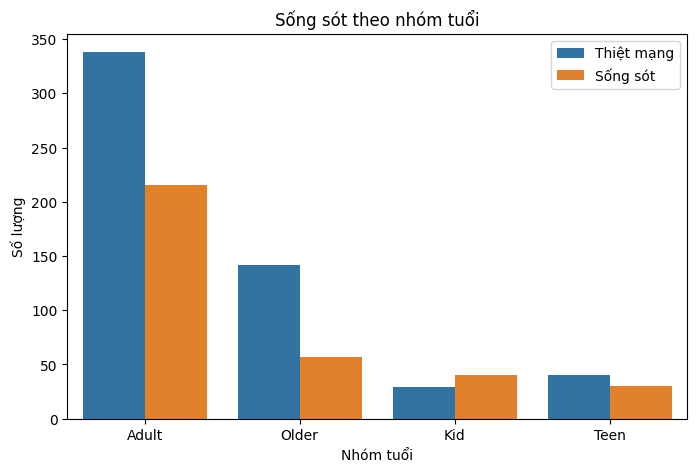

<Figure size 1000x500 with 0 Axes>

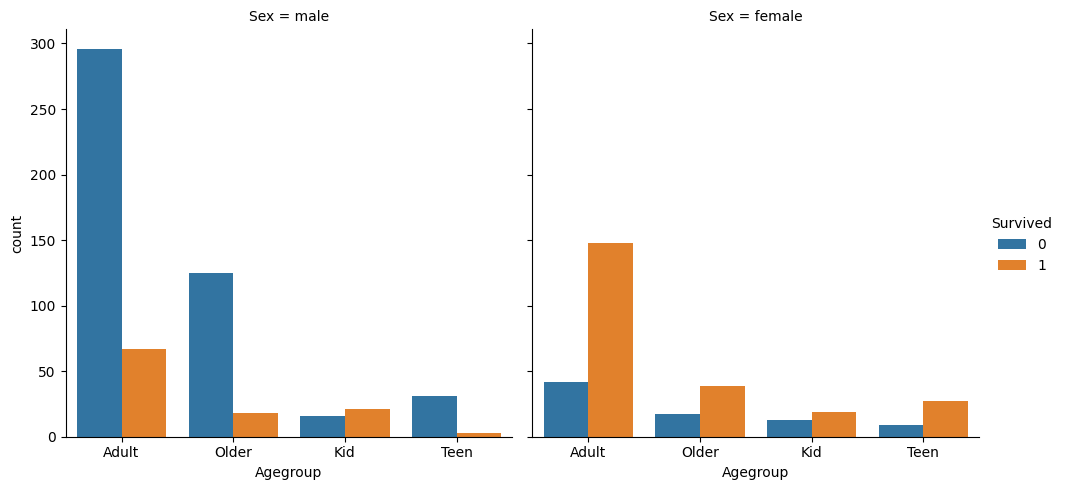

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x="Agegroup",
    hue="Survived",
    data=df
)

plt.title("Sống sót theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Số lượng")
plt.legend(["Thiệt mạng", "Sống sót"])
plt.show()

# Theo giới tính và nhóm tuổi
plt.figure(figsize=(10,5))

sns.catplot(
    x="Agegroup",
    hue="Survived",
    col="Sex",
    data=df,
    kind="count",
    height=5,
    aspect=1
)

plt.show()

NHẬN XÉT :
-Trẻ em có tỷ lệ sống sót khá cao.
-Nữ giới sống sót nhiều hơn nam ở hầu hết các nhóm tuổi.
-Nam trưởng thành có tỷ lệ thiệt mạng cao nhất.

CÂU 15

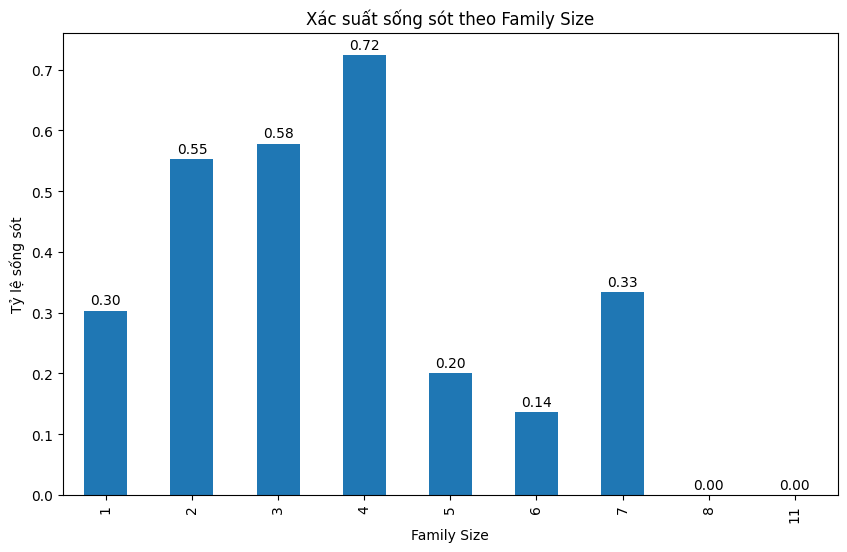

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

survival_rate = df.groupby("familySize")["Survived"].mean()

plt.figure(figsize=(10,6))
ax = survival_rate.plot(kind="bar")

plt.title("Xác suất sống sót theo Family Size")
plt.xlabel("Family Size")
plt.ylabel("Tỷ lệ sống sót")

for i, v in enumerate(survival_rate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

NHẬN XÉT :
-Người đi một mình hoặc đi theo nhóm nhỏ thường có tỷ lệ sống sót cao hơn.
-Nhóm quá đông thường có tỷ lệ sống sót thấp hơn.

CÂU 16

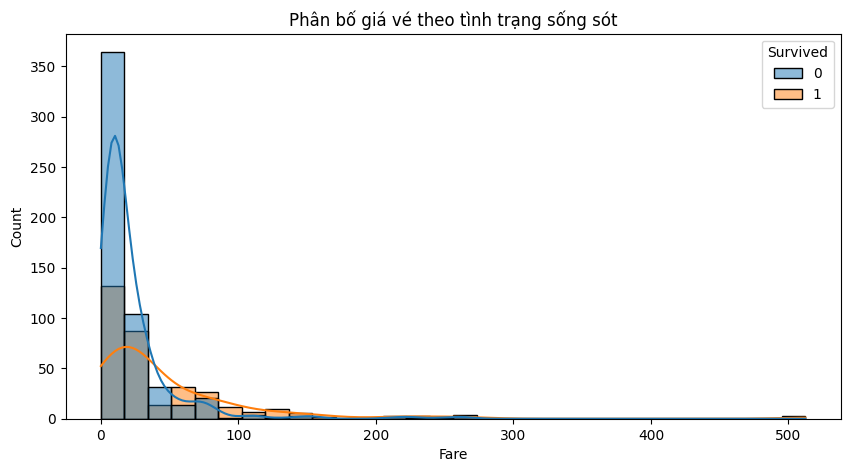

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Fare",
    hue="Survived",
    kde=True,
    bins=30
)

plt.title("Phân bố giá vé theo tình trạng sống sót")
plt.show()

NHẬN XÉT :
-Hành khách có giá vé cao thường có xác suất sống sót cao hơn.
-Hành khách vé rẻ tập trung nhiều ở nhóm thiệt mạng.
-Điều này liên quan đến việc hành khách hạng 1 thường mua vé đắt và được ưu tiên cứu hộ hơn.

CÂU 17

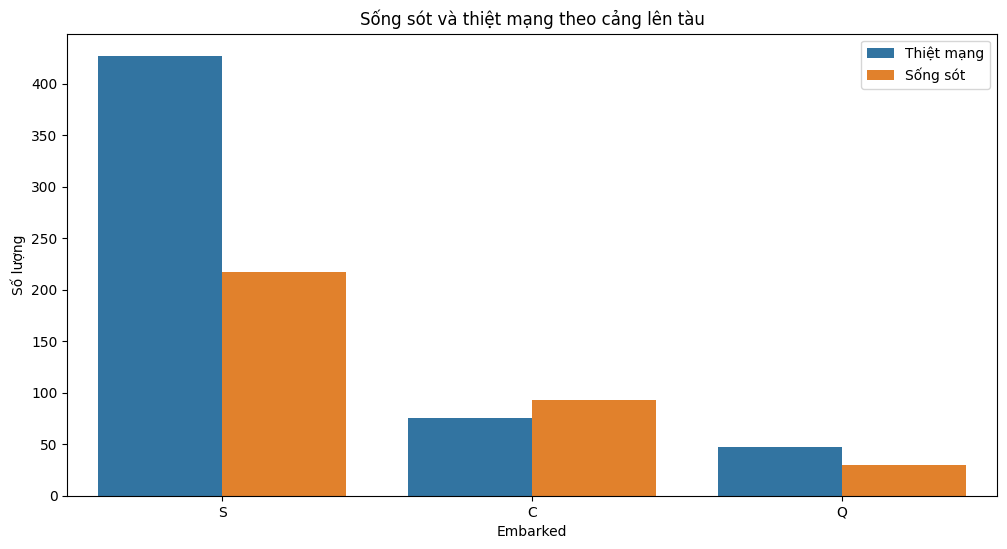

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Embarked",
    hue="Survived",
    data=df
)

plt.title("Sống sót và thiệt mạng theo cảng lên tàu")
plt.xlabel("Embarked")
plt.ylabel("Số lượng")
plt.legend(["Thiệt mạng", "Sống sót"])

plt.show()

NHẬN XÉT :
-Hành khách Pclass S có số lượng sống sót cao hơn các hạng khác.
-Hành khách Pclass Q có số lượng thiệt mạng lớn nhất.
-Cảng Southampton có nhiều hành khách nhất nên cũng có số lượng sống sót và thiệt mạng cao nhất.
-Nhóm hành khách lên tàu tại Cherbourg thường có tỷ lệ sống sót cao hơn do có nhiều hành khách thuộc hạng 1.
-Kết quả cho thấy Pclass và Embarked đều ảnh hưởng đến khả năng sống sót của hành khách Titanic.